# Parsed and Annotated Data

## LIB

The LIB table contains metadata for each document in the corpus. Each document corresponds to a single essay from either the Federalist Papers or the Anti-Federalist Papers. These are long-form political essays written during the ratification debates of the U.S. Constitution (1787–1788).

    book_id | doc_no | title | author | group | date

In [2]:
import sys
!{sys.executable} -m pip install pypdf

In [3]:
import re
from pathlib import Path

import pandas as pd
import requests
from bs4 import BeautifulSoup
from pypdf import PdfReader

In [4]:
## ---- Anti-Federalist Papers ---- ##

ANTI_PDF = Path("TheAntiFederalistPapers.pdf")

def extract_antifederalist(pdf_path=ANTI_PDF):
    reader = PdfReader(str(pdf_path))

    # Pull text from pages after the contents/title pages
    raw = "\n".join((page.extract_text() or "") for page in reader.pages[5:])

    # Clean line-break hyphenation and normalize spacing
    raw = re.sub(r"-\n(?=\w)", "", raw)
    raw = re.sub(r"\r", "\n", raw)
    raw = re.sub(r"[ \t]+", " ", raw)

    # Keep only the essay area starting at No. 1
    m = re.search(r"Antifederalist No\.\s*1\b", raw, flags=re.I)
    if m:
        raw = raw[m.start():]

    # Split essays
    chunks = re.split(r"(?=Antifederalist No\.\s*\d+(?:-\d+)?(?:\s*\([^)]+\))?)", raw)
    chunks = [c.strip() for c in chunks if c.strip()]

    records = []
    for i, chunk in enumerate(chunks, start=1):
        head = " ".join(chunk.splitlines()[:5]).strip()

        m_no = re.search(r"Antifederalist No\.\s*([0-9]+(?:-[0-9]+)?)", head, flags=re.I)
        doc_no = m_no.group(1) if m_no else str(i)

        # Title = heading line after the number, before "From ..." if present
        title = head
        title = re.sub(r"^Antifederalist No\.\s*[0-9]+(?:-[0-9]+)?\s*", "", title, flags=re.I)
        title = re.sub(r"\s+From\s+.*$", "", title, flags=re.I).strip()
        title = re.sub(r"\s{2,}", " ", title)

        m_date = re.search(
            r"(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},\s+\d{4}",
            chunk
        )
        date = m_date.group(0) if m_date else ""

        # Best-effort signer/author extraction
        sig = re.search(r"\n([A-Z][A-Z\s\-\.\[\]]{3,})\s*$", chunk.strip())
        author = sig.group(1).strip() if sig else "UNKNOWN"

        # Remove heading clutter from the essay text
        text = re.sub(r"^Antifederalist No\.\s*[0-9]+(?:-[0-9]+)?\s*", "", chunk, flags=re.I).strip()
        text = re.sub(r"\s+", " ", text)

        records.append({
            "doc_id": f"anti_{doc_no}",
            "doc_no": doc_no,
            "title": title,
            "date": date,
            "author": author,
            "group": "anti",
            "text": text
        })

    return pd.DataFrame(records).set_index("doc_id")

In [5]:
## ---- Federalist Papers ---- ##

import json
import pandas as pd
from pathlib import Path

FED_JSON = Path("federalist.json")

def extract_federalist_json(json_path=FED_JSON):
    records = []

    with open(json_path, 'r') as f:
        for line in f:
            obj = json.loads(line)

            doc_no = obj.get("paper_id")
            text = obj.get("text", "")
            title = obj.get("title", "")
            author = obj.get("author", "UNKNOWN")
            date = obj.get("date") or ""

            # clean text (match class style)
            text = re.sub(r"\s+", " ", text).strip()

            records.append({
                "doc_id": f"fed_{doc_no}",
                "doc_no": str(doc_no),
                "title": title,
                "date": date,
                "author": author,
                "group": "federalist",
                "text": text
            })

    df = pd.DataFrame(records).set_index("doc_id")
    return df

In [6]:
## ---- Ratification Debate Corpus (Virginia JSON) ---- ##

# ----------------------------
# 1. Load JSON
# ----------------------------

with open("virginia_debates.json", "r") as f:
    data = json.load(f)

# ----------------------------
# 2. Extract documents
# ----------------------------

records = []

for i, (title, paragraphs) in enumerate(data['text'].items()):
    
    # join paragraphs into full document
    text = " ".join(paragraphs)
    
    # clean spacing
    text = re.sub(r"\s+", " ", text)
    
    records.append({
        "doc_id": f"rat_{i}",
        "doc_no": str(i),
        "title": title,
        "author": "MULTIPLE",  # debates involve many speakers
        "group": "ratification_debate",
        "date": "",  # optional
        "text": text
    })

# ----------------------------
# 3. Create DataFrame
# ----------------------------

RAT = pd.DataFrame(records).set_index("doc_id")
RAT['date'] = RAT['title'].str.extract(r'^(June \d{1,2}, 1788)')

# ----------------------------
# 4. Check
# ----------------------------

print("RAT shape:", RAT.shape)
RAT.head()

RAT shape: (32, 6)


,doc_no,title,author,group,date,text
doc_id,,,,,,
rat_0,0,"June 2, 1788, Journal Notes Of The Virginia Ra...",MULTIPLE,ratification_debate,"June 2, 1788",This being the day recommended by the Legisla...
rat_1,1,"June 2, 1788, Edmund Pendleton Address To The ...",MULTIPLE,ratification_debate,"June 2, 1788",Gentn. The Distinguished Honr. of being calle...
rat_2,2,"June 3, 1788, Journal Notes Of The Virginia Ra...",MULTIPLE,ratification_debate,"June 3, 1788",Mr. Harrison reported from the Committee of P...
rat_3,3,"June 5, 1788, Journal Notes Of The Virginia Ra...",MULTIPLE,ratification_debate,"June 5, 1788",Mr. Harrison reported from the Committee of P...
rat_4,4,"June 7, 1788, Journal Notes Of The Virginia Ra...",MULTIPLE,ratification_debate,"June 7, 1788","ir option to assume constructive power, danger..."


In [7]:
# --- create combined LIB ---- #

FED = extract_federalist_json()
AF = extract_antifederalist()
ALL_DOCS = pd.concat([FED, AF, RAT])

LIB = pd.concat([FED, AF, RAT]).copy()

LIB.index.name = 'book_id'

LIB = LIB[['doc_no', 'title', 'author', 'group', 'date']]

LIB


Ignoring wrong pointing object 5 0 (offset 0)


,doc_no,title,author,group,date
book_id,,,,,
fed_1,1,General Introduction,HAMILTON,federalist,
fed_2,2,Concerning Dangers from Foreign Force and Infl...,JAY,federalist,
fed_3,3,The Same Subject Continued (Concerning Dangers...,JAY,federalist,
fed_4,4,The Same Subject Continued (Concerning Dangers...,JAY,federalist,
fed_5,5,The Same Subject Continued (Concerning Dangers...,JAY,federalist,
...,...,...,...,...,...
rat_27,27,"July 21, 1788, Affidavit Of Thomas Merriwether",MULTIPLE,ratification_debate,NaN
rat_28,28,"July 26, 1788, Newspaper Report Of Antifederal...",MULTIPLE,ratification_debate,NaN
rat_29,29,"July 27, 1788, A Spectators Notes Of The Antif...",MULTIPLE,ratification_debate,NaN


In [8]:
LIB.to_csv('LIB.csv', sep='|')

In [9]:
LIB['char_len'] = pd.concat([FED, AF, RAT])['text'].str.len()
avg_len = LIB['char_len'].mean()
avg_len

np.float64(18148.30964467005)

# CORPUS

In [10]:
import sys
!{sys.executable} -m pip install nltk

import nltk
nltk.download('averaged_perceptron_tagger')

import nltk
nltk.download('averaged_perceptron_tagger_eng')

## ---- Build CORPUS (Token Table) ---- ##

import pandas as pd
import re
import nltk

# download tagger (only runs once)
nltk.download('averaged_perceptron_tagger')

# ----------------------------
# 1. Combine all documents
# ----------------------------

ALL_DOCS = pd.concat([FED, AF, RAT]).copy()

# ----------------------------
# 2. Tokenize text
# ----------------------------

CORPUS = ALL_DOCS['text'].str.split().explode().to_frame('token_str')

# ----------------------------
# 3. Create OHCO index
# ----------------------------

CORPUS['book_id'] = CORPUS.index
CORPUS['token_num'] = CORPUS.groupby('book_id').cumcount()

CORPUS = CORPUS.set_index(['book_id', 'token_num'])

# ----------------------------
# 4. Normalize tokens
# ----------------------------

CORPUS['term_str'] = (
    CORPUS['token_str']
    .str.lower()
    .str.replace(r'[^a-z]', '', regex=True)
)

# remove empty tokens
CORPUS = CORPUS[CORPUS['term_str'] != '']

# ----------------------------
# 5. POS tagging (IMPORTANT)
# ----------------------------

# tag using cleaned terms
pos_tags = nltk.pos_tag(CORPUS['term_str'].tolist())

CORPUS['pos'] = [tag for word, tag in pos_tags]

# ----------------------------
# 6. POS grouping
# ----------------------------

def pos_group(tag):
    if tag.startswith('N'):
        return 'NOUN'
    elif tag.startswith('V'):
        return 'VERB'
    elif tag.startswith('J'):
        return 'ADJ'
    elif tag.startswith('R'):
        return 'ADV'
    else:
        return 'OTHER'

CORPUS['pos_group'] = CORPUS['pos'].apply(pos_group)

print("Total tokens:", len(CORPUS))

CORPUS.to_csv("CORPUS.csv", sep="|")

CORPUS

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/steveferenzi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/steveferenzi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/steveferenzi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Total tokens: 606097


token_str       term_str  pos pos_group
book_id token_num                                              
fed_1   0                      To             to   TO     OTHER
        1                     the            the   DT     OTHER
        2                  People         people  NNS      NOUN
        3                      of             of   IN     OTHER
        4                     the            the   DT     OTHER
...                           ...            ...  ...       ...
rat_31  388               manner,         manner   NN      NOUN
        389                    on             on   IN     OTHER
        390                   the            the   DT     OTHER
        391             gentlemen      gentlemen  NNS      NOUN
        392        commissioners.  commissioners  NNS      NOUN

[606097 rows x 4 columns]

# VOCAB

In [11]:
## ---- Build VOCAB (Term Table) ---- ##

import numpy as np
from nltk.stem import PorterStemmer

# ----------------------------
# 1. Initialize
# ----------------------------

ps = PorterStemmer()

# ----------------------------
# 2. Term frequency (n)
# ----------------------------

VOCAB = CORPUS['term_str'].value_counts().to_frame('n')
VOCAB.index.name = 'term_str'

# ----------------------------
# 3. Probability (p)
# ----------------------------

VOCAB['p'] = VOCAB['n'] / VOCAB['n'].sum()

# ----------------------------
# 4. Document Frequency (df)
# ----------------------------

df = CORPUS.reset_index().groupby('term_str')['book_id'].nunique()
VOCAB['df'] = df

# ----------------------------
# 5. Inverse Document Frequency (idf)
# ----------------------------

N_docs = CORPUS.index.get_level_values('book_id').nunique()
VOCAB['idf'] = np.log(N_docs / VOCAB['df'])

# ----------------------------
# 6. DFIDF (importance metric)
# ----------------------------

VOCAB['dfidf'] = VOCAB['df'] * VOCAB['idf']

# ----------------------------
# 7. Porter Stem
# ----------------------------

VOCAB['porter_stem'] = VOCAB.index.map(ps.stem)

# ----------------------------
# 8. Most common POS
# ----------------------------

pos_mode = CORPUS.reset_index().groupby('term_str')['pos'] \
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)

VOCAB['max_pos'] = pos_mode

# ----------------------------
# 9. POS Group
# ----------------------------

pos_group_mode = CORPUS.reset_index().groupby('term_str')['pos_group'] \
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)

VOCAB['max_pos_group'] = pos_group_mode

# ----------------------------
# 10. Stopword flag
# ----------------------------

stop_words = {
    'the','and','of','to','in','a','is','it','that','for','on','with',
    'as','are','this','was','be','by','or','an','at','from','which'
}

VOCAB['stop'] = VOCAB.index.isin(stop_words)

# ----------------------------
# 11. Sort by importance
# ----------------------------

VOCAB = VOCAB.sort_values('dfidf', ascending=False)

# ----------------------------
# 12. Top 20 terms
# ----------------------------

top20 = VOCAB.head(20).index.tolist()

print("Top 20 terms by DFIDF:")
for i, term in enumerate(top20, 1):
    print(f"{i}. {term}")

# ----------------------------
# 13. Save VOCAB
# ----------------------------

VOCAB.to_csv("VOCAB.csv", sep="|")

VOCAB

Top 20 terms by DFIDF:
1. objection
2. called
3. things
4. measure
5. establish
6. provided
7. branch
8. confederation
9. advantage
10. use
11. essential
12. propriety
13. office
14. importance
15. private
16. occasion
17. happen
18. want
19. property
20. individual


,n,p,df,idf,dfidf,porter_stem,max_pos,max_pos_group,stop
term_str,,,,,,,,,
objection,233,0.000384,72,0.996333,71.736008,object,NN,NOUN,False
called,185,0.000305,72,0.996333,71.736008,call,VBN,VERB,False
things,169,0.000279,72,0.996333,71.736008,thing,NNS,NOUN,False
measure,135,0.000223,72,0.996333,71.736008,measur,NN,NOUN,False
establish,123,0.000203,72,0.996333,71.736008,establish,VB,VERB,False
...,...,...,...,...,...,...,...,...,...
as,4987,0.008228,194,0.005141,0.997432,as,IN,OTHER,True
in,12402,0.020462,195,0.000000,0.000000,in,IN,OTHER,True
of,30364,0.050098,195,0.000000,0.000000,of,IN,OTHER,True


# Derived Tables

## BOW

In [12]:
## ---- Build BOW (Bag of Words) ---- ##

# ----------------------------
# 1. Define bag level
# ----------------------------
# We use document-level bags (book_id)

BAG = ['book_id']

# ----------------------------
# 2. Count term frequencies per document
# ----------------------------

BOW = CORPUS.groupby(BAG + ['term_str']).size().to_frame('n')

# ----------------------------
# 3. Add TF (term frequency)
# ----------------------------

# total tokens per document
doc_lengths = CORPUS.groupby('book_id').size()

# normalize counts
BOW['tf'] = BOW['n'] / doc_lengths.reindex(BOW.index.get_level_values('book_id')).values

# ----------------------------
# 4. Add IDF from VOCAB
# ----------------------------

BOW['idf'] = BOW.index.get_level_values('term_str').map(VOCAB['idf'])

# ----------------------------
# 5. Compute TFIDF
# ----------------------------

BOW['tfidf'] = BOW['tf'] * BOW['idf']

# ----------------------------
# 6. Check size
# ----------------------------

print("BOW observations:", len(BOW))

# ----------------------------
# 7. Save
# ----------------------------

BOW.to_csv("BOW.csv", sep="|")

# preview
BOW

BOW observations: 146801


n        tf       idf     tfidf
book_id term_str                                    
anti_1  a           14  0.016037  0.005141  0.000082
        abated       1  0.001145  5.273000  0.006040
        abuse        1  0.001145  1.401799  0.001606
        act          1  0.001145  0.729705  0.000836
        additional   1  0.001145  1.360977  0.001559
...                 ..       ...       ...       ...
rat_9   yoke         1  0.000071  3.663562  0.000259
        you          5  0.000354  1.284016  0.000454
        young        1  0.000071  2.500411  0.000177
        your         4  0.000283  1.401799  0.000397
        zealous      1  0.000071  2.970414  0.000210

[146801 rows x 4 columns]

## DTM

In [13]:
## ---- Build DTM (Document-Term Matrix) ---- ##

import pandas as pd

# ----------------------------
# 1. Pivot BOW into matrix
# ----------------------------

DTM = BOW['n'].unstack(fill_value=0)

# ----------------------------
# 2. Check shape
# ----------------------------

print("DTM shape:", DTM.shape)

# ----------------------------
# 3. Save
# ----------------------------

DTM.to_csv("DTM.csv", sep="|")

# preview
DTM

DTM shape: (195, 16174)


term_str,a,aaron,aarons,ab,abandon,abandoned,abandoning,abandonment,abate,abated,...,zaleucus,zane,zeal,zealand,zealots,zealous,zealously,zealthe,zenith,zones
book_id,,,,,,,,,,,,,,,,,,,,,
anti_1,14,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,2,0,0,0,0
anti_10,32,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
anti_11,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anti_12,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anti_13,35,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rat_5,324,0,0,0,0,2,0,1,0,0,...,0,0,2,0,0,0,0,0,0,0
rat_6,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rat_7,340,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## TFIDF

In [14]:
## ---- Build TFIDF Matrix ---- ##

# ----------------------------
# 1. Pivot TFIDF values
# ----------------------------

TFIDF = BOW['tfidf'].unstack(fill_value=0)

# ----------------------------
# 2. Check shape
# ----------------------------

print("TFIDF shape:", TFIDF.shape)

# ----------------------------
# 3. Save
# ----------------------------

TFIDF.to_csv("TFIDF.csv", sep="|")

# preview
TFIDF

TFIDF shape: (195, 16174)


term_str,a,aaron,aarons,ab,abandon,abandoned,abandoning,abandonment,abate,abated,...,zaleucus,zane,zeal,zealand,zealots,zealous,zealously,zealthe,zenith,zones
book_id,,,,,,,,,,,,,,,,,,,,,
anti_1,0.000082,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00604,...,0.0,0.0,0.000000,0.0,0.00604,0.006805,0.0,0.0,0.0,0.0
anti_10,0.000075,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000880,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
anti_11,0.000104,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
anti_12,0.000065,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
anti_13,0.000118,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rat_5,0.000091,0.0,0.0,0.0,0.000000,0.000314,0.0,0.000228,0.0,0.00000,...,0.0,0.0,0.000212,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
rat_6,0.000107,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0
rat_7,0.000080,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.00000,...,0.0,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0


## Reduced and Normalized TFIDF_L2

In [15]:
## ---- L2-Normalized TFIDF (Filtered for PCA) ---- ##

import numpy as np

# ----------------------------
# 1. Compute L2 norm per document
# ----------------------------

norms = np.sqrt((TFIDF ** 2).sum(axis=1))

# ----------------------------
# 2. Normalize each row
# ----------------------------

TFIDF_L2 = TFIDF.div(norms, axis=0)

# ----------------------------
# 3. Fill any NaNs (if a doc was empty)
# ----------------------------

TFIDF_L2 = TFIDF_L2.fillna(0)

# ----------------------------
# 4. FILTER TERMS (IMPORTANT)
# Keep only meaningful words
# ----------------------------

BAD_TERMS = {
    'mr', 'sir', 'gentleman', 'gentlemen',
    'honorable', 'col', 'colonel'
}

GOOD_TERMS = VOCAB[
    (VOCAB['stop'] == False) &
    (VOCAB['max_pos_group'].isin(['NOUN', 'ADJ'])) &
    (~VOCAB.index.isin(BAD_TERMS))
].index

TFIDF_L2_REDUCED = TFIDF_L2[GOOD_TERMS]

# ----------------------------
# 5. Check shapes
# ----------------------------

print("Original shape:", TFIDF_L2.shape)
print("Reduced shape:", TFIDF_L2_REDUCED.shape)

# ----------------------------
# 6. Save BOTH (important)
# ----------------------------

TFIDF_L2.to_csv("TFIDF_L2.csv", sep="|")                # full (for assignment)
TFIDF_L2_REDUCED.to_csv("TFIDF_L2_REDUCED.csv", sep="|")  # filtered (for PCA)

# preview
TFIDF_L2_REDUCED

Original shape: (195, 16174)
Reduced shape: (195, 10400)


term_str,objection,things,measure,branch,confederation,advantage,use,essential,propriety,office,...,tobe,minutiae,propertywhen,dissolvedthe,landsthe,jurywhere,hominem,practiceis,principleit,nameto
book_id,,,,,,,,,,,,,,,,,,,,,
anti_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017927,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
anti_10,0.000000,0.011234,0.022468,0.011392,0.011392,0.000000,0.000000,0.000000,0.011392,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
anti_11,0.000000,0.028546,0.000000,0.014473,0.014473,0.000000,0.014473,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
anti_12,0.000000,0.011937,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012104,0.012104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
anti_13,0.000000,0.013364,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rat_5,0.014037,0.016376,0.004679,0.007117,0.014234,0.011861,0.014234,0.002372,0.009489,0.002372,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
rat_6,0.000000,0.000000,0.020622,0.006971,0.000000,0.000000,0.006971,0.000000,0.013941,0.006971,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
rat_7,0.020574,0.005143,0.005143,0.018255,0.065195,0.023470,0.013039,0.007823,0.018255,0.015647,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Models

## PCA Components

In [16]:
## ---- PCA Components ---- ##

from sklearn.decomposition import PCA

# ----------------------------
# 1. Initialize PCA
# ----------------------------

pca = PCA(n_components=5, random_state=42)

# ----------------------------
# 2. Fit PCA on TFIDF_L2_REDUCED
# ----------------------------

X_pca = pca.fit_transform(TFIDF_L2_REDUCED)

# ----------------------------
# 3. Create component table
# ----------------------------

PC = pd.DataFrame(

    pca.components_,

    columns=TFIDF_L2_REDUCED.columns,

    index=[f'PC{i}' for i in range(5)]

)

PC

term_str,objection,things,measure,branch,confederation,advantage,use,essential,propriety,office,...,tobe,minutiae,propertywhen,dissolvedthe,landsthe,jurywhere,hominem,practiceis,principleit,nameto
PC0,0.002041,-0.003378,-0.005422,-0.014122,-0.006979,-0.013966,-0.000338,0.003289,0.012150,-0.007359,...,0.001668,0.002439,0.002439,0.001668,0.001668,0.001668,0.001668,0.001668,0.002439,0.002439
PC1,0.016171,-0.016565,0.001818,0.087198,-0.041637,0.021578,-0.013773,0.012305,0.020871,0.128193,...,-0.000762,-0.000298,-0.000298,-0.000762,-0.000762,-0.000762,-0.000762,-0.000762,-0.000298,-0.000298
PC2,-0.033754,-0.026609,-0.017879,-0.027728,-0.048655,-0.041301,-0.024486,-0.035406,-0.025251,0.019717,...,0.001504,-0.000201,-0.000201,0.001504,0.001504,0.001504,0.001504,0.001504,-0.000201,-0.000201
PC3,0.006817,0.010391,0.000830,0.043282,0.057071,-0.010318,0.010715,-0.024474,-0.013082,0.087821,...,0.001006,0.001294,0.001294,0.001006,0.001006,0.001006,0.001006,0.001006,0.001294,0.001294
PC4,-0.037082,-0.004672,-0.003165,-0.035250,0.003386,-0.033605,0.014885,0.001071,-0.005184,0.041993,...,-0.001837,-0.000326,-0.000326,-0.001837,-0.001837,-0.001837,-0.001837,-0.001837,-0.000326,-0.000326


In [17]:
# Top positive terms (PC0)

PC.loc['PC0'].sort_values(ascending=False).head(5)

term_str
courts          0.419431
court           0.341752
jury            0.255082
jurisdiction    0.249842
appellate       0.186542
Name: PC0, dtype: float64

In [18]:
# Top negative terms (PC1)

PC.loc['PC1'].sort_values().head(5)


term_str
taxes      -0.118659
congress   -0.095448
taxation   -0.080603
militia    -0.075868
revenue    -0.072836
Name: PC1, dtype: float64

## PCA DCM

In [44]:

DCM = pd.DataFrame(
    X_pca,
    index=TFIDF_L2_REDUCED.index,
    columns=[f'PC{i}' for i in range(5)]
)

DCM.to_csv("PCA_DCM.csv", sep="|")

DCM

,PC0,PC1,PC2,PC3,PC4
book_id,,,,,
anti_1,-0.061395,-0.014004,0.083276,-0.046593,-0.004715
anti_10,-0.064566,-0.028898,-0.003168,-0.044631,-0.057473
anti_11,-0.027934,-0.101046,-0.046288,-0.017679,-0.023263
anti_12,-0.052191,-0.127847,0.082010,0.031222,0.029872
anti_13,-0.030387,-0.073682,0.071406,0.035531,0.010699
...,...,...,...,...,...
rat_5,-0.038520,-0.103581,-0.065932,0.140893,-0.004150
rat_6,-0.075461,-0.040381,0.281722,-0.147821,0.078766
rat_7,0.004983,-0.126089,-0.186381,0.198771,-0.002133


## PCA Loadings

In [20]:
PC = pd.DataFrame(
    pca.components_,
    columns=TFIDF_L2_REDUCED.columns,
    index=[f'PC{i}' for i in range(5)]
)

PC.to_csv("PCA_LOADINGS.csv", sep="|")

PC

term_str,objection,things,measure,branch,confederation,advantage,use,essential,propriety,office,...,tobe,minutiae,propertywhen,dissolvedthe,landsthe,jurywhere,hominem,practiceis,principleit,nameto
PC0,0.002041,-0.003378,-0.005422,-0.014122,-0.006979,-0.013966,-0.000338,0.003289,0.012150,-0.007359,...,0.001668,0.002439,0.002439,0.001668,0.001668,0.001668,0.001668,0.001668,0.002439,0.002439
PC1,0.016171,-0.016565,0.001818,0.087198,-0.041637,0.021578,-0.013773,0.012305,0.020871,0.128193,...,-0.000762,-0.000298,-0.000298,-0.000762,-0.000762,-0.000762,-0.000762,-0.000762,-0.000298,-0.000298
PC2,-0.033754,-0.026609,-0.017879,-0.027728,-0.048655,-0.041301,-0.024486,-0.035406,-0.025251,0.019717,...,0.001504,-0.000201,-0.000201,0.001504,0.001504,0.001504,0.001504,0.001504,-0.000201,-0.000201
PC3,0.006817,0.010391,0.000830,0.043282,0.057071,-0.010318,0.010715,-0.024474,-0.013082,0.087821,...,0.001006,0.001294,0.001294,0.001006,0.001006,0.001006,0.001006,0.001006,0.001294,0.001294
PC4,-0.037082,-0.004672,-0.003165,-0.035250,0.003386,-0.033605,0.014885,0.001071,-0.005184,0.041993,...,-0.001837,-0.000326,-0.000326,-0.001837,-0.001837,-0.001837,-0.001837,-0.001837,-0.000326,-0.000326


## PCA Visualization 1 

In [21]:
# --- document scatterplot (PC0 vs PC1) ---

import plotly.express as px

# join group info
DCM_plot = DCM.join(LIB[['group']])

fig = px.scatter(
    DCM_plot,
    x='PC0',
    y='PC1',
    color='group',
    title='PCA Document Projection (PC0 vs PC1)',
    hover_name=DCM_plot.index
)

fig.show()

In [22]:
# --- loadings scatterplot ---

loadings_plot = PC.T.reset_index()
loadings_plot.columns = ['term', 'PC0', 'PC1', 'PC2', 'PC3', 'PC4']

fig = px.scatter(
    loadings_plot,
    x='PC0',
    y='PC1',
    title='PCA Loadings (PC0 vs PC1)',
    hover_name='term'
)

fig.show()

## PCA Visualization 2

In [23]:
# --- document scatterplot (PC1 vs PC2) ---

DCM_plot = DCM.join(LIB[['group']])

fig = px.scatter(
    DCM_plot,
    x='PC1',
    y='PC2',
    color='group',
    title='PCA Document Projection (PC1 vs PC2)',
    hover_name=DCM_plot.index
)

fig.show()

In [24]:
# --- loadings scatterplot (PC1 vs PC2) ---

loadings_plot = PC.T.reset_index()
loadings_plot.columns = ['term', 'PC0', 'PC1', 'PC2', 'PC3', 'PC4']

fig = px.scatter(
    loadings_plot,
    x='PC1',
    y='PC2',
    title='PCA Loadings (PC1 vs PC2)',
    hover_name='term'
)

fig.show()

## LDA TOPIC

In [25]:
## ---- LDA Topic Model (Filtered) ---- ##

from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

# ----------------------------
# 1. Filter vocabulary for LDA
# ----------------------------

# keep meaningful terms only
GOOD_TERMS_LDA = VOCAB[
    (VOCAB['stop'] == False) &
    (VOCAB['max_pos_group'].isin(['NOUN'])) &
    (~VOCAB.index.str.contains(r'[^a-z]')) &   # remove weird tokens
    (VOCAB.index.str.len() > 2)               # remove very short tokens
].index

# ----------------------------
# 2. Filter DTM
# ----------------------------

DTM_LDA = DTM[GOOD_TERMS_LDA]

print("DTM_LDA shape:", DTM_LDA.shape)

# ----------------------------
# 3. Initialize LDA
# ----------------------------

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='batch',
    random_state=42
)

# ----------------------------
# 4. Fit model
# ----------------------------

THETA = lda.fit_transform(DTM_LDA)

# ----------------------------
# 5. Topic-term matrix
# ----------------------------

PHI = pd.DataFrame(
    lda.components_,
    columns=DTM_LDA.columns,
    index=[f'T{i:02d}' for i in range(n_topics)]
)

# ----------------------------
# 6. Document-topic matrix
# ----------------------------

THETA = pd.DataFrame(
    THETA,
    index=DTM_LDA.index,
    columns=[f'T{i:02d}' for i in range(n_topics)]
)

# ----------------------------
# 7. Extract top words
# ----------------------------

TOP_WORDS = {
    topic: PHI.loc[topic].sort_values(ascending=False).head(5).index.tolist()
    for topic in PHI.index
}

print("\nTop words per topic:")
for t, words in TOP_WORDS.items():
    print(t, ":", words)

# ----------------------------
# 8. Rank topics by importance
# ----------------------------

topic_means = THETA.mean().sort_values(ascending=False)

print("\nTopic importance (mean weight):")
print(topic_means)

# ----------------------------
# 9. Save outputs
# ----------------------------

PHI.to_csv("LDA_TOPIC_TERM.csv", sep="|")
THETA.to_csv("LDA_DOC_TOPIC.csv", sep="|")

DTM_LDA shape: (195, 7589)

Top words per topic:
T00 : ['people', 'government', 'power', 'state', 'men']
T01 : ['states', 'state', 'constitution', 'power', 'law']
T02 : ['president', 'people', 'government', 'power', 'executive']
T03 : ['government', 'states', 'power', 'people', 'congress']
T04 : ['government', 'states', 'state', 'union', 'people']

Topic importance (mean weight):
T00    0.325038
T04    0.255520
T01    0.177029
T03    0.150300
T02    0.092114
dtype: float64


## LDA THETA

In [26]:
THETA.to_csv("LDA_THETA.csv", sep="|")

THETA

,T00,T01,T02,T03,T04
book_id,,,,,
anti_1,0.001033,0.001023,0.995884,0.001029,0.001031
anti_10,0.920475,0.000431,0.000430,0.032575,0.046089
anti_11,0.172737,0.101528,0.000480,0.128567,0.596688
anti_12,0.000622,0.000621,0.000619,0.954582,0.043556
anti_13,0.749600,0.000614,0.000606,0.248571,0.000609
...,...,...,...,...,...
rat_5,0.000052,0.016738,0.292907,0.690251,0.000052
rat_6,0.033779,0.000697,0.000699,0.068159,0.896666
rat_7,0.000042,0.000043,0.000042,0.994625,0.005248


## LDA PHI

In [27]:
PHI.to_csv("LDA_PHI.csv", sep="|")
PHI

term_str,objection,things,measure,branch,confederation,advantage,use,propriety,office,importance,...,lance,provisionit,hendersons,minutiae,propertywhen,landsthe,jurywhere,hominem,practiceis,principleit
T00,63.488766,32.055544,38.322253,113.067388,40.080611,59.141808,37.499898,38.639425,133.751332,36.722490,...,0.2,0.2,0.2,0.20000,0.20000,0.2,0.2,0.2,0.2,0.20000
T01,44.838643,27.172165,11.072231,9.664246,41.720415,10.815989,31.287172,38.552341,34.361101,31.524916,...,1.2,1.2,1.2,1.19998,1.19998,1.2,1.2,1.2,1.2,1.19998
T02,0.326741,3.510387,4.890723,16.036320,7.745582,5.590128,6.006297,2.830242,46.718638,5.461431,...,0.2,0.2,0.2,0.20000,0.20000,0.2,0.2,0.2,0.2,0.20000
T03,79.003590,74.560528,54.285304,28.296335,205.146508,51.977925,61.137127,38.700626,22.982031,18.866091,...,0.2,0.2,0.2,0.20002,0.20002,0.2,0.2,0.2,0.2,0.20002
T04,46.342260,32.701376,27.429489,20.935711,38.306883,38.474151,38.069506,35.277366,1.186899,45.425072,...,0.2,0.2,0.2,0.20000,0.20000,0.2,0.2,0.2,0.2,0.20000


## LDA + PCA Visualization

In [42]:
## ---- LDA + PCA Visualization (Topics) ---- ##

from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

# ----------------------------
# 1. Transpose THETA (topics as rows)
# ----------------------------

THETA_T = THETA.T  # rows = topics, cols = documents

# ----------------------------
# 2. Apply PCA to topics
# ----------------------------

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(THETA_T)

TOPIC_PCA = pd.DataFrame(
    Z,
    index=THETA_T.index,
    columns=['PC0', 'PC1']
)

# ----------------------------
# 3. Topic size (mean weight)
# ----------------------------

TOPIC_PCA['size'] = THETA.mean()

# ----------------------------
# 4. Assign dominant group to each topic
# ----------------------------

topic_group = {}

for topic in THETA.columns:
    # document where topic is strongest
    top_doc = THETA[topic].idxmax()
    
    # assign that document's group
    topic_group[topic] = LIB.loc[top_doc, 'group']

TOPIC_PCA['group'] = pd.Series(topic_group)

# ----------------------------
# 5. Plot
# ----------------------------

fig = px.scatter(
    TOPIC_PCA,
    x='PC0',
    y='PC1',
    size='size',
    color='group',
    text=TOPIC_PCA.index,
    title='LDA Topics in PCA Space (PC0 vs PC1)'
)

fig.show()

## Sentiment VOCAB_SENT 

In [43]:
## ---- Sentiment: VOCAB_SENT (Bing Lexicon) ---- ##

# ----------------------------
# 1. Load lexicon
# ----------------------------

LEX = pd.read_csv("salex_bing.csv")

# ----------------------------
# 2. Keep only needed columns
# ----------------------------

LEX = LEX[['term_str', 'bing_sentiment']]

# rename for consistency
LEX = LEX.rename(columns={'bing_sentiment': 'sentiment'})

# ----------------------------
# 3. Join with VOCAB
# ----------------------------

VOCAB_SENT = VOCAB.join(
    LEX.set_index('term_str'),
    how='inner'
)

# ----------------------------
# 4. Add polarity label (optional but nice)
# ----------------------------

VOCAB_SENT['polarity'] = VOCAB_SENT['sentiment'].map({
    1: 'positive',
    -1: 'negative'
})

# ----------------------------
# 5. Check
# ----------------------------

print("VOCAB size:", len(VOCAB))
print("VOCAB_SENT size:", len(VOCAB_SENT))

print("\nSentiment distribution:")
print(VOCAB_SENT['polarity'].value_counts())

VOCAB_SENT

# ----------------------------
# 6. Save
# ----------------------------

VOCAB_SENT.to_csv("VOCAB_SENT.csv", sep="|")

VOCAB size: 16174
VOCAB_SENT size: 2434

Sentiment distribution:
polarity
negative    1596
positive     837
Name: count, dtype: int64


In [30]:
VOCAB_SENT

,n,p,df,idf,dfidf,porter_stem,max_pos,max_pos_group,stop,sentiment,polarity
term_str,,,,,,,,,,,
objection,233,0.000384,72,0.996333,71.736008,object,NN,NOUN,False,-1,negative
advantage,165,0.000272,71,1.010320,71.732697,advantag,NN,NOUN,False,1,positive
objections,160,0.000264,73,0.982540,71.725429,object,NNS,NOUN,False,-1,negative
confidence,155,0.000256,75,0.955511,71.663358,confid,NN,NOUN,False,1,positive
secure,245,0.000404,75,0.955511,71.663358,secur,VB,VERB,False,1,positive
...,...,...,...,...,...,...,...,...,...,...,...
litigious,1,0.000002,1,5.273000,5.273000,litigi,JJ,ADJ,False,-1,negative
culprit,1,0.000002,1,5.273000,5.273000,culprit,NN,NOUN,False,-1,negative
brutality,1,0.000002,1,5.273000,5.273000,brutal,NN,NOUN,False,-1,negative


## Sentiment BOW_SENT

In [31]:
## ---- Sentiment: BOW_SENT ---- ##

# ----------------------------
# 1. Join sentiment onto BOW
# ----------------------------

BOW_SENT = BOW.join(
    VOCAB_SENT[['sentiment']],
    on='term_str',
    how='inner'   # keep only words with sentiment
)

# ----------------------------
# 2. Check
# ----------------------------

print("BOW size:", len(BOW))
print("BOW_SENT size:", len(BOW_SENT))

BOW_SENT

# ----------------------------
# 3. Save
# ----------------------------

BOW_SENT.to_csv("BOW_SENT.csv", sep="|")

BOW size: 146801
BOW_SENT size: 21665


In [32]:
BOW_SENT

n        tf       idf     tfidf  sentiment
book_id term_str                                             
anti_1  abuse      1  0.001145  1.401799  0.001606         -1
        advocates  2  0.002291  1.321756  0.003028          1
        afraid     1  0.001145  2.439786  0.002795         -1
        astray     1  0.001145  3.886705  0.004452         -1
        bait       1  0.001145  4.174387  0.004782         -1
...               ..       ...       ...       ...        ...
rat_9   wisely     1  0.000071  2.564949  0.000181          1
        worth      1  0.000071  2.564949  0.000181          1
        worthy     3  0.000212  1.635413  0.000347          1
        wretched   1  0.000071  3.193558  0.000226         -1
        zealous    1  0.000071  2.970414  0.000210         -1

[21665 rows x 5 columns]

## Sentiment DOC_SENT

In [33]:
## ---- Sentiment: DOC_SENT ---- ##

# ----------------------------
# 1. Compute sentiment per document
# ----------------------------

DOC_SENT = BOW_SENT.groupby('book_id').agg({
    'sentiment': ['sum', 'mean']
})

# flatten column names
DOC_SENT.columns = ['sent_sum', 'sent_mean']

# ----------------------------
# 2. Add metadata (group)
# ----------------------------

DOC_SENT = DOC_SENT.join(LIB[['group']])

# ----------------------------
# 3. Check
# ----------------------------

print("\nSummary by group:")
print(DOC_SENT.groupby('group')[['sent_sum', 'sent_mean']].mean())

# ----------------------------
# 4. Save
# ----------------------------

DOC_SENT.to_csv("DOC_SENT.csv", sep="|")


Summary by group:
                      sent_sum  sent_mean
group                                    
anti                  0.500000   0.021467
federalist           -1.894118   0.003559
ratification_debate -31.875000  -0.061070


In [34]:
DOC_SENT

,sent_sum,sent_mean,group
book_id,,,
anti_1,-12,-0.162162,anti
anti_10,-4,-0.028571,anti
anti_11,18,0.225000,anti
anti_12,-8,-0.114286,anti
anti_13,26,0.406250,anti
...,...,...,...
rat_5,-59,-0.109870,ratification_debate
rat_6,6,0.130435,ratification_debate
rat_7,-72,-0.142292,ratification_debate


## Sentiment Plot 

In [35]:
# ----------------------------
# 1. Bar chart (group averages)
# ----------------------------

group_sent = DOC_SENT.groupby('group')['sent_mean'].mean().reset_index()

fig = px.bar(
    group_sent,
    x='group',
    y='sent_mean',
    title='Average Sentiment by Group',
    labels={'sent_mean': 'Average Sentiment'}
)

fig.show()

## VOCAB_W2V

In [36]:
## ---- Word2Vec: VOCAB_W2V ---- ##

from gensim.models import Word2Vec
import pandas as pd

# ----------------------------
# 1. Build sentences (by document)
# ----------------------------

sentences = CORPUS.reset_index().groupby('book_id')['term_str'].apply(list).tolist()

# ----------------------------
# 2. Train Word2Vec model
# ----------------------------

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # number of features
    window=5,
    min_count=5,
    workers=1,
    seed=42
)

# ----------------------------
# 3. Extract embeddings
# ----------------------------

words = list(w2v_model.wv.index_to_key)

VOCAB_W2V = pd.DataFrame(
    w2v_model.wv[words],
    index=words
)

VOCAB_W2V.index.name = 'term_str'

# ----------------------------
# 4. Join with VOCAB
# ----------------------------

VOCAB_W2V = VOCAB.join(VOCAB_W2V, how='inner')

# ----------------------------
# 5. Check
# ----------------------------

print("VOCAB_W2V shape:", VOCAB_W2V.shape)
display(VOCAB_W2V.head())

# ----------------------------
# 6. Save
# ----------------------------

VOCAB_W2V.to_csv("VOCAB_W2V.csv", sep="|")

VOCAB_W2V shape: (5691, 109)


,n,p,df,idf,dfidf,porter_stem,max_pos,max_pos_group,stop,0,...,90,91,92,93,94,95,96,97,98,99
term_str,,,,,,,,,,,,,,,,,,,,,
objection,233,0.000384,72,0.996333,71.736008,object,NN,NOUN,False,0.028757,...,-0.724923,0.341780,0.069514,-0.045118,0.370595,-0.062326,0.049723,-0.544941,-0.203652,0.101680
called,185,0.000305,72,0.996333,71.736008,call,VBN,VERB,False,0.124574,...,-0.448617,0.341647,0.038556,-0.000641,0.413573,-0.219166,0.021455,0.056342,-0.232256,-0.385657
things,169,0.000279,72,0.996333,71.736008,thing,NNS,NOUN,False,0.227131,...,-0.046983,0.219946,-0.084760,-0.167431,0.167662,-0.538236,0.033924,0.039219,-0.046215,-0.014414
measure,135,0.000223,72,0.996333,71.736008,measur,NN,NOUN,False,0.162936,...,-0.246110,0.415232,-0.019888,-0.131282,0.188946,-0.275872,0.083161,-0.114908,-0.162297,0.030595
establish,123,0.000203,72,0.996333,71.736008,establish,VB,VERB,False,0.083935,...,-0.070425,0.220261,-0.051623,-0.233660,0.253139,-0.094425,-0.327731,0.167770,-0.115186,-0.242220


## Word2vec tSNE Plot


In [37]:
## ---- Word2Vec t-SNE Plot ---- ##

from sklearn.manifold import TSNE


# ----------------------------
# 1. Select embedding columns
# ----------------------------

embedding_cols = [col for col in VOCAB_W2V.columns if isinstance(col, int)]

X = VOCAB_W2V[embedding_cols]

# optional: reduce to top frequent words for clarity
top_words = VOCAB_W2V.sort_values('n', ascending=False).head(500).index
X = X.loc[top_words]

# ----------------------------
# 2. Run t-SNE
# ----------------------------

tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(X)

# ----------------------------
# 3. Build dataframe
# ----------------------------

TSNE_DF = pd.DataFrame(X_tsne, columns=['x', 'y'], index=X.index)

# ----------------------------
# 4. Plot
# ----------------------------

fig = px.scatter(
    TSNE_DF,
    x='x',
    y='y',
    text=TSNE_DF.index,
    title='Word2Vec t-SNE Plot'
)

fig.update_traces(textposition='top center')

fig.show()

# Riffs

## Riff 1 - Sentiment Over Time

In [38]:
LIB['date'].notna().sum()

np.int64(192)

In [39]:
## ---- Riff: Sentiment Over Time ---- ##

# ----------------------------
# 1. Merge sentiment with metadata
# ----------------------------

SENT_TIME = DOC_SENT.join(LIB[['date']])

# ----------------------------
# 2. Clean + convert dates
# ----------------------------

# drop missing dates
SENT_TIME = SENT_TIME.dropna(subset=['date'])

# convert to datetime (safe)
SENT_TIME['date'] = pd.to_datetime(SENT_TIME['date'], errors='coerce')

# drop any failed conversions
SENT_TIME = SENT_TIME.dropna(subset=['date'])

# ----------------------------
# 3. Sort by time
# ----------------------------

SENT_TIME = SENT_TIME.sort_values('date')

# ----------------------------
# 4. Smooth sentiment (rolling mean)
# ----------------------------

SENT_TIME['sent_smooth'] = (
    SENT_TIME
    .groupby('group')['sent_mean']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

# ----------------------------
# 5. Plot
# ----------------------------

fig = px.line(
    SENT_TIME,
    x='date',
    y='sent_smooth',
    color='group',
    title='Sentiment Over Time by Group',
    labels={'sent_smooth': 'Smoothed Sentiment'}
)

fig.show()

## Riff 2 - LDA Topic Distribution by Group

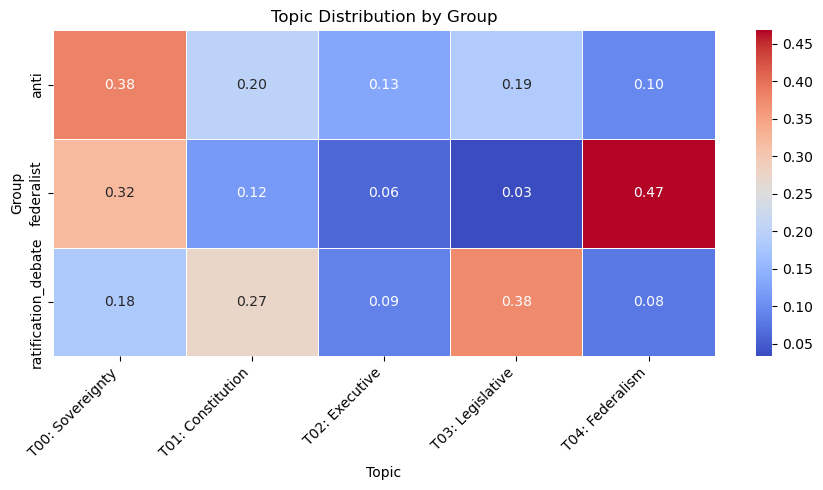

In [40]:
## ---- Riff: LDA Topic Heatmap ---- ##

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# 1. Merge THETA with group
# ----------------------------

THETA_GROUP = THETA.join(LIB[['group']])

# ----------------------------
# 2. Compute average topic weight per group
# ----------------------------

topic_group = THETA_GROUP.groupby('group').mean()

# ----------------------------
# 3. Define clean topic labels
# (make sure these match your LDA section)
# ----------------------------

topic_labels = {
    'T00': 'T00: Sovereignty',
    'T01': 'T01: Constitution',
    'T02': 'T02: Executive',
    'T03': 'T03: Legislative',
    'T04': 'T04: Federalism'
}

# apply labels
topic_group_labeled = topic_group.rename(columns=topic_labels)

# ----------------------------
# 4. Plot heatmap
# ----------------------------

plt.figure(figsize=(9, 5))

sns.heatmap(
    topic_group_labeled,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.xticks(rotation=45, ha='right')
plt.title("Topic Distribution by Group")
plt.ylabel("Group")
plt.xlabel("Topic")

plt.tight_layout()
plt.show()

## Riff 3 - Anti-Federalist Concerns

In [41]:
## ---- Riff: Anti-Federalist Concerns (Topic Comparison) ---- ##

# ----------------------------
# 1. Merge THETA with group
# ----------------------------

THETA_GROUP = THETA.join(LIB[['group']])

# ----------------------------
# 2. Compute mean topic weights by group
# ----------------------------

topic_means = THETA_GROUP.groupby('group').mean()

# ----------------------------
# 3. Define clean topic labels
# ----------------------------

topic_labels = {
    'T00': 'Sovereignty',
    'T01': 'Constitution',
    'T02': 'Executive',
    'T03': 'Legislative',
    'T04': 'Federalism'
}

topic_means = topic_means.rename(columns=topic_labels)

# ----------------------------
# 4. Convert to long format for plotting
# ----------------------------

topic_long = topic_means.reset_index().melt(
    id_vars='group',
    var_name='Topic',
    value_name='Average Weight'
)

# ----------------------------
# 5. Plot 
# ----------------------------

fig = px.bar(
    topic_long,
    x='Topic',
    y='Average Weight',
    color='group',
    barmode='group',
    title='Topic Emphasis by Group (Anti-Federalist vs Others)'
)

fig.show()
